In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

In [4]:
# Loading the sample dataset

data = load_iris()
X=data.data
y = data.target

In [8]:
# train,test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# standardization

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# initialize and fit lda model

lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test = lda.transform(X_test_scaled)

In [15]:
# predict

y_pred = lda.predict(X_test_scaled)

In [17]:
# accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f"reduced shape of X_train: {X_train_lda.shape}")

Accuracy: 1.0
reduced shape of X_train: (120, 2)


In [18]:
from matplotlib import pyplot as plt
import math
from sklearn import datasets
import pandas as pd


In [19]:
iris = load_iris()
X= iris.data
Y = iris.target

In [20]:
label_dict = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

In [21]:
np.set_printoptions(precision=4)

In [22]:
mean_vectors = []
for cl in range(0,3):
  mean_vectors.append(np.mean(X[Y==cl], axis=0))
  print(f"Mean Vector class {cl+1}: {mean_vectors[cl]}")

Mean Vector class 1: [5.006 3.428 1.462 0.246]
Mean Vector class 2: [5.936 2.77  4.26  1.326]
Mean Vector class 3: [6.588 2.974 5.552 2.026]


In [25]:
# scatter matrix computation

S_W = np.zeros((4,4))
for cl,mv in zip(range(0,3), mean_vectors):
  # General Scatter Matrix
  # Filling the MAtrix with values of 0 to initialize
  class_sc_mat= np.zeros((4,4))

  # for every row in our dataset where the class corresponds to the respective iteration

  for row in X[Y==cl]:
    # 1x4 -> 4x1 for convenience
    row,mv = row.reshape(4,1),mv.reshape(4,1)
    # apply the eqn and make the sum

    class_sc_mat += (row-mv).dot((row-mv).T)
  # Sum the scatter matrices
  S_W += class_sc_mat

print(S_W)


[[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]


In [26]:
# inter class scatter matrix

overall_mean = np.mean(X, axis=0)

#Filling the mat with 0 to initialize
S_b = np.zeros((4,4))

for i,mean_vec in enumerate(mean_vectors):
  # Extract number of samples per class, in this case, 50
  n = X[Y==i, :].shape[0]

  mean_vec=mean_vec.reshape(4,1)
  overall_mean = overall_mean.reshape(4,1)

  S_b += n* (mean_vec-overall_mean).dot((mean_vec - overall_mean).T)

print(S_b)

[[ 63.2121 -19.9527 165.2484  71.2793]
 [-19.9527  11.3449 -57.2396 -22.9327]
 [165.2484 -57.2396 437.1028 186.774 ]
 [ 71.2793 -22.9327 186.774   80.4133]]


In [30]:
# solving generalized eigenvalue problem for the matrix inv(S_W)*S_b

eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(S_W).dot(S_b))


for i in range(len(eigenvalues)):
  eigenvectors_sc = eigenvectors[:, i].reshape(4,1)
  print()
  print(f"Eigenvector {i+1}: \n{eigenvectors_sc.real}")
  print(f"Eigenvalue {i+1}: {eigenvalues[i].real: .2e}");




Eigenvector 1: 
[[-0.2087]
 [-0.3862]
 [ 0.554 ]
 [ 0.7074]]
Eigenvalue 1:  3.22e+01

Eigenvector 2: 
[[-0.0065]
 [-0.5866]
 [ 0.2526]
 [-0.7695]]
Eigenvalue 2:  2.85e-01

Eigenvector 3: 
[[-0.1416]
 [-0.2125]
 [-0.2703]
 [ 0.6927]]
Eigenvalue 3: -2.89e-15

Eigenvector 4: 
[[-0.1416]
 [-0.2125]
 [-0.2703]
 [ 0.6927]]
Eigenvalue 4: -2.89e-15


In [32]:
for i in range(len(eigenvectors)):
  eigv= eigenvectors[:,i].reshape(4,1)
  np.testing.assert_array_almost_equal(np.linalg.inv(S_W).dot(S_b).dot(eigv), eigenvalues[i]*eigv, decimal = 6, err_msg = '', verbose=True)
print("ok")

ok


In [33]:
# we can test that if this were not true, it would raise an exception
for i in range(len(eigenvectors)):
  eigv= np.array([6,6,6,6]).reshape(4,1)
  np.testing.assert_array_almost_equal(np.linalg.inv(S_W).dot(S_b).dot(eigv), eigenvalues[i]*eigv, decimal = 6, err_msg = '', verbose=True)
print("ok")


AssertionError: 
Arrays are not almost equal to 6 decimals

Mismatched elements: 4 / 4 (100%)
Max absolute difference among violations: 341.0862
Max relative difference among violations: 1.7659
 ACTUAL: array([[ -81.285356],
       [-147.934632],
       [ 214.730255],
       [ 278.829794]])
 DESIRED: array([[193.151575+0.j],
       [193.151575+0.j],
       [193.151575+0.j],
       [193.151575+0.j]])

In [34]:
# selecting LDs for new features subspace

eigenpairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]

eigenpairs = sorted(eigenpairs, key=lambda k: k[0], reverse=True)

print('Eigenvalues in decreasing order: \n')

for i in eigenpairs:
  print(i[0])

Eigenvalues in decreasing order: 

32.191929198278025
0.28539104262306647
3.7355530009793716e-15
3.7355530009793716e-15


In [35]:
print("Variance expained:\n")
eigenvalues_sum = sum(eigenvalues)
for i,j in enumerate(eigenpairs):
  print(f"Eigenvalue {i+1}: {((j[0]/eigenvalues_sum).real): .2%}")

Variance expained:

Eigenvalue 1:  99.12%
Eigenvalue 2:  0.88%
Eigenvalue 3:  0.00%
Eigenvalue 4:  0.00%


In [37]:
# the first eigenvalue is the most informative as it explains 99.2% of variance in the data

W = np.hstack((eigenpairs[0][1].reshape(4,1), eigenpairs[1][1].reshape(4,1)))


print(f"MAtrix W: \n{W.real}")

MAtrix W: 
[[-0.2087 -0.0065]
 [-0.3862 -0.5866]
 [ 0.554   0.2526]
 [ 0.7074 -0.7695]]


In [38]:
# now we transform the samples onto the new subspace , i.e Y = X x W


X_lda = X.dot(W)

assert X_lda.shape == (150,2)

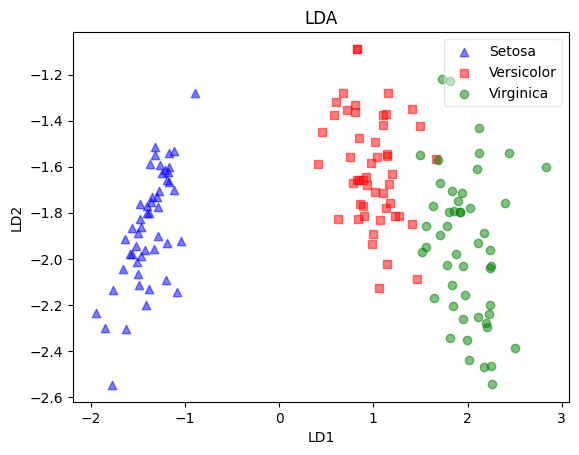

In [42]:
# no error above, so we're fine

# lets now plot the points in the new 2 dimensional feature space


def plot_step_lda():
  ax=plt.subplot(111)
  for label,marker,color in zip(
      range(0,3),('^','s','o'),('blue','red','green')):
      plt.scatter(x=X_lda[:,0].real[Y==label], y=X_lda[:,1].real[Y==label], marker=marker, color=color, alpha=0.5, label=label_dict[label])
  plt.xlabel("LD1")
  plt.ylabel("LD2")

  leg = plt.legend(loc='upper right', fancybox=True)
  leg.get_frame().set_alpha(0.5)
  plt.title("LDA")
  plt.show()
plot_step_lda()